# 전처리

## 0. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## 1. 파일 가져오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder = Path('/content/drive/MyDrive/부동산')

# csv, txt 파일만 가져오기
files = [
    f for f in folder.iterdir()
    if f.suffix.lower() in ['.csv', '.txt']
    and not f.name.startswith('._')
    and re.search(r'\d{4}', f.name)
]

# 파일명에서 연도 추출
def get_year(file_path):
    match = re.search(r'(\d{4})', file_path.name)
    return int(match.group(1)) if match else 9999

# 2021년부터 2025년까지만 필터링
files = [
    f for f in files
    if 2021 <= get_year(f) <= 2025
]

# 연도 기준 정렬
files = sorted(files, key=get_year)

print("파일 개수:", len(files))
for f in files:
    print(f.name)

Mounted at /content/drive
파일 개수: 5
서울특별시_전월세가_2021.txt
서울특별시_전월세가_2022.csv
서울특별시_전월세가_2023.csv
서울특별시_전월세가_2024.csv
서울특별시_전월세가_2025.csv


## 2. 인코딩/구분자 자동 감지

In [3]:
def read_file_auto(path):
    encodings = ['utf-8-sig', 'cp949', 'euc-kr', 'utf-16', 'latin1']
    seps = [',', '\t', '|', ';']

    for enc in encodings:
        for sep in seps:
            try:
                temp = pd.read_csv(
                    path,
                    encoding=enc,
                    sep=sep,
                    engine='python',
                    on_bad_lines='skip'
                )

                # 컬럼이 2개 이상이면 정상적으로 읽힌 것으로 판단
                if temp.shape[1] > 1:
                    temp.columns = temp.columns.astype(str).str.strip()
                    return temp, enc, sep

            except Exception:
                continue

    raise ValueError(f"읽기 실패: {path.name}")

## 3. 계약기간을 개월 수로 변환
예: '23.01~25.01' -> 24

In [4]:
def calc_contract_months(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ['', 'nan', 'NaN', '미제공', '0', 'Unknown']:
        return np.nan

    x = x.replace("’", "'").replace("‘", "'")
    x = x.replace(" ", "")

    match = re.match(r'(\d{2})\.(\d{2})~(\d{2})\.(\d{2})', x)

    if not match:
        return np.nan

    start_y, start_m, end_y, end_m = map(int, match.groups())

    start_y += 2000
    end_y += 2000

    months = (end_y - start_y) * 12 + (end_m - start_m)

    if months <= 0:
        return np.nan

    return months

## 4. 모든 연도 파일 통합

In [5]:
dfs = []

for file in files:
    year = get_year(file)
    print("읽는 중:", year, file.name)

    temp, enc, sep = read_file_auto(file)
    temp['파일연도'] = year

    # 컬럼명 공백 제거
    temp.columns = temp.columns.astype(str).str.strip()

    # 계약기간 / 신규계약구분 / 갱신청구권사용 컬럼이 있으면 처리
    if '계약기간' in temp.columns:
        temp['계약기간'] = temp['계약기간'].astype('string').fillna('미제공').str.strip()
        temp['계약기간_개월'] = temp['계약기간'].apply(calc_contract_months)
        temp['계약기간_결측여부'] = temp['계약기간_개월'].isna().astype(int)

    if '신규계약구분' in temp.columns:
        temp['신규계약구분'] = temp['신규계약구분'].astype('string').fillna('미제공').str.strip()
        temp['신규계약구분'] = temp['신규계약구분'].replace({
            'nan': '미제공',
            'NaN': '미제공',
            '': '미제공'
        })

        # 신규 = 1, 갱신 = 0
        temp['신규계약여부'] = np.where(
            temp['신규계약구분'] == '신규', 1,
            np.where(temp['신규계약구분'] == '갱신', 0, np.nan)
        )

        temp['계약구분_결측여부'] = temp['신규계약구분'].eq('미제공').astype(int)

    if '갱신청구권사용' in temp.columns:
        temp['갱신청구권사용'] = temp['갱신청구권사용'].astype('string').fillna('미제공').str.strip()

        # O = 사용, 미제공 = 결측, 나머지 = 미사용
        temp['갱신청구권사용여부'] = np.where(
            temp['갱신청구권사용'] == 'O', 1,
            np.where(temp['갱신청구권사용'] == '미제공', np.nan, 0)
        )

        temp['갱신청구권_결측여부'] = temp['갱신청구권사용'].eq('미제공').astype(int)

    dfs.append(temp)

df_all = pd.concat(dfs, ignore_index=True)

print("통합 완료:", df_all.shape)
df_all.head()

읽는 중: 2021 서울특별시_전월세가_2021.txt
읽는 중: 2022 서울특별시_전월세가_2022.csv
읽는 중: 2023 서울특별시_전월세가_2023.csv
읽는 중: 2024 서울특별시_전월세가_2024.csv
읽는 중: 2025 서울특별시_전월세가_2025.csv
통합 완료: (3238096, 30)


,접수년도,자치구코드,자치구명,법정동코드,법정동명,지번구분코드,지번구분,본번,부번,층,...,갱신청구권사용,종전보증금,종전임대료,파일연도,계약기간_개월,계약기간_결측여부,신규계약여부,계약구분_결측여부,갱신청구권사용여부,갱신청구권_결측여부
0,2021,11170.0,용산구,11300.0,원효로2가,1.0,대지,1.0,0.0,6.0,...,미제공,NaN,NaN,2021,NaN,1,NaN,1,NaN,1
1,2021,11170.0,용산구,11300.0,원효로2가,1.0,대지,1.0,0.0,6.0,...,미제공,NaN,NaN,2021,NaN,1,NaN,1,NaN,1
2,2021,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,5.0,...,미제공,NaN,NaN,2021,NaN,1,NaN,1,NaN,1
3,2021,11440.0,마포구,11000.0,노고산동,1.0,대지,1.0,1.0,9.0,...,미제공,NaN,NaN,2021,NaN,1,NaN,1,NaN,1
4,2021,11545.0,금천구,10200.0,독산동,1.0,대지,1006.0,54.0,2.0,...,미제공,NaN,NaN,2021,NaN,1,NaN,1,NaN,1


## 5. 기본 숫자형 변환

In [6]:
num_cols = [
    '임대면적',
    '보증금(만원)',
    '임대료(만원)',
    '층',
    '건축년도',
    '종전보증금',
    '종전임대료',
    '자치구코드',
    '법정동코드',
    '접수년도'
]

for col in num_cols:
    if col in df_all.columns:
        df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

## 6. 월세 데이터만 추출

In [7]:
df_all['전월세구분'] = df_all['전월세구분'].astype(str).str.strip()

monthly_df = df_all[df_all['전월세구분'] == '월세'].copy()

print("전체 데이터:", df_all.shape)
print("월세 데이터:", monthly_df.shape)

전체 데이터: (3238096, 30)
월세 데이터: (1754985, 30)


## 7. 계약연도, 계약월 생성

In [8]:
monthly_df['계약일_str'] = (
    monthly_df['계약일']
    .astype('string')
    .str.replace('-', '', regex=False)
    .str.strip()
)

monthly_df['계약연도'] = pd.to_numeric(
    monthly_df['계약일_str'].str[:4],
    errors='coerce'
)

monthly_df['계약월'] = pd.to_numeric(
    monthly_df['계약일_str'].str[4:6],
    errors='coerce'
)

# 이상한 월은 NaN 처리
monthly_df.loc[~monthly_df['계약월'].between(1, 12), '계약월'] = np.nan

# 계약연도 0은 NaN 처리
monthly_df.loc[monthly_df['계약연도'] == 0, '계약연도'] = np.nan

monthly_df[['계약일', '계약연도', '계약월']].head()

,계약일,계약연도,계약월
0,20210317,2021,3
2,20201202,2020,12
4,20210302,2021,3
9,20210201,2021,2
10,20210805,2021,8


## 8. 임대면적, 평수, 평당가격 생성

In [9]:
# 0 이하 값은 계산 불가능하므로 NaN 처리
monthly_df.loc[monthly_df['임대면적'] <= 0, '임대면적'] = np.nan
monthly_df.loc[monthly_df['보증금(만원)'] <= 0, '보증금(만원)'] = np.nan
monthly_df.loc[monthly_df['임대료(만원)'] <= 0, '임대료(만원)'] = np.nan

# 평수 생성
monthly_df['평수'] = monthly_df['임대면적'] / 3.3

# 평당가격: 월세 / 평수
monthly_df['평당가격'] = monthly_df['임대료(만원)'] / monthly_df['평수']

# 평당 보증금
monthly_df['평당_보증금'] = monthly_df['보증금(만원)'] / monthly_df['평수']

monthly_df[['임대면적', '평수', '보증금(만원)', '임대료(만원)', '평당가격', '평당_보증금']].head()

,임대면적,평수,보증금(만원),임대료(만원),평당가격,평당_보증금
0,21.45,6.500000,500.0,33.0,5.076923,76.923077
2,33.66,10.200000,10000.0,55.0,5.392157,980.392157
4,17.67,5.354545,500.0,50.0,9.337861,93.378608
9,74.55,22.590909,1000.0,55.0,2.434608,44.265594
10,15.75,4.772727,6000.0,10.0,2.095238,1257.142857


## 9. 면적 기준 필터링
2평 이상 & 50㎡ 미만으로 필터링

In [10]:
df = monthly_df.copy()

df = df[
    (df['임대면적'].notna()) &
    (df['임대면적'] < 50) &
    (df['평수'] >= 2)
].copy()

print("면적 필터링 후:", df.shape)
print("최소 평수:", df['평수'].min())
print("최대 평수:", df['평수'].max())

면적 필터링 후: (1243751, 36)
최소 평수: 2.175757575757576
최대 평수: 15.150606060606062


## 10. 법정동명 / 법정동코드 / 자치구명 / 자치구코드 결측 제거
위치 정보는 분석 핵심 변수라 결측이면 제거

In [11]:
location_cols = ['법정동명', '법정동코드', '자치구명', '자치구코드']

existing_location_cols = [col for col in location_cols if col in df.columns]

df = df.dropna(subset=existing_location_cols).copy()

print("위치 정보 결측 제거 후:", df.shape)

위치 정보 결측 제거 후: (1243751, 36)


## 11. 건물나이 생성

In [12]:
# 0은 잘못된 값으로 보고 NaN 처리
df.loc[df['건축년도'] == 0, '건축년도'] = np.nan


# 건물나이 생성
df['건물나이'] = df['계약연도'] - df['건축년도']

# 건축년도가 계약연도보다 큰 경우 NaN 처리
df.loc[df['건물나이'] < 0, '건물나이'] = np.nan


df[['계약연도', '건축년도', '건물나이']].head()

,계약연도,건축년도,건물나이
0,2021,1990.0,31.0
2,2020,1998.0,22.0
4,2021,2014.0,7.0
10,2021,2015.0,6.0
13,2021,2015.0,6.0


## 12. 지하여부 생성

In [13]:
def check_basement(x):
    if pd.isna(x):
        return np.nan

    x_str = str(x).strip()

    if '지하' in x_str:
        return 1

    try:
        if float(x_str) <= 0:
            return 1
    except:
        return np.nan

    return 0


# 지하여부 먼저 생성
df['지하여부'] = df['층'].apply(check_basement)

# 이후 층 숫자형 변환
df['층'] = pd.to_numeric(df['층'], errors='coerce')

df[['층', '지하여부']].head()

,층,지하여부
0,6.0,0.0
2,5.0,0.0
4,2.0,0.0
10,4.0,0.0
13,5.0,0.0


## 13. 제도 관련 변수 결측 처리
값을 대체하지 않고 NaN 그대로 유지

In [14]:
# 계약기간_개월
if '계약기간_개월' in df.columns:
    df['계약기간_결측여부'] = df['계약기간_개월'].isna().astype(int)

# 신규계약여부
if '신규계약여부' in df.columns:
    df['신규계약여부_결측여부'] = df['신규계약여부'].isna().astype(int)

# 갱신청구권사용여부
if '갱신청구권사용여부' in df.columns:
    df['갱신청구권_결측여부'] = df['갱신청구권사용여부'].isna().astype(int)

# 종전보증금, 종전임대료
for col in ['종전보증금', '종전임대료']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[f'{col}_결측여부'] = df[col].isna().astype(int)

## 14. 불필요한 컬럼 제거

In [15]:
drop_cols = [
    '본번',
    '부번',
    '건물명',
    '지번구분',
    '지번구분코드',
    '계약일_str'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("컬럼 제거 후:", df.shape)

컬럼 제거 후: (1243751, 35)


## 15. 이상치 제거

==================== 변수별 상세 분위수 (상위 구간) ====================
       임대료(만원)  보증금(만원)  건물나이    층
0.5000    50.0  2,000.0  12.0  5.0
0.9000    85.0 13,000.0  34.0 14.0
0.9500   100.0 18,815.6  37.0 16.0
0.9900   150.0 27,100.0  51.0 23.0
0.9950   180.0 30,000.0  55.0 26.0
0.9990   280.0 40,000.0  68.0 33.0
0.9999   450.0 70,000.0  92.0 42.0

[참고] 최소값 / 최대값 범위
 - 임대료(만원): 최소 1.0 / 최대 9,600.0
 - 보증금(만원): 최소 1.0 / 최대 294,000.0
 - 건물나이: 최소 0.0 / 최대 1,025.0
 - 층: 최소 -4.0 / 최대 601.0


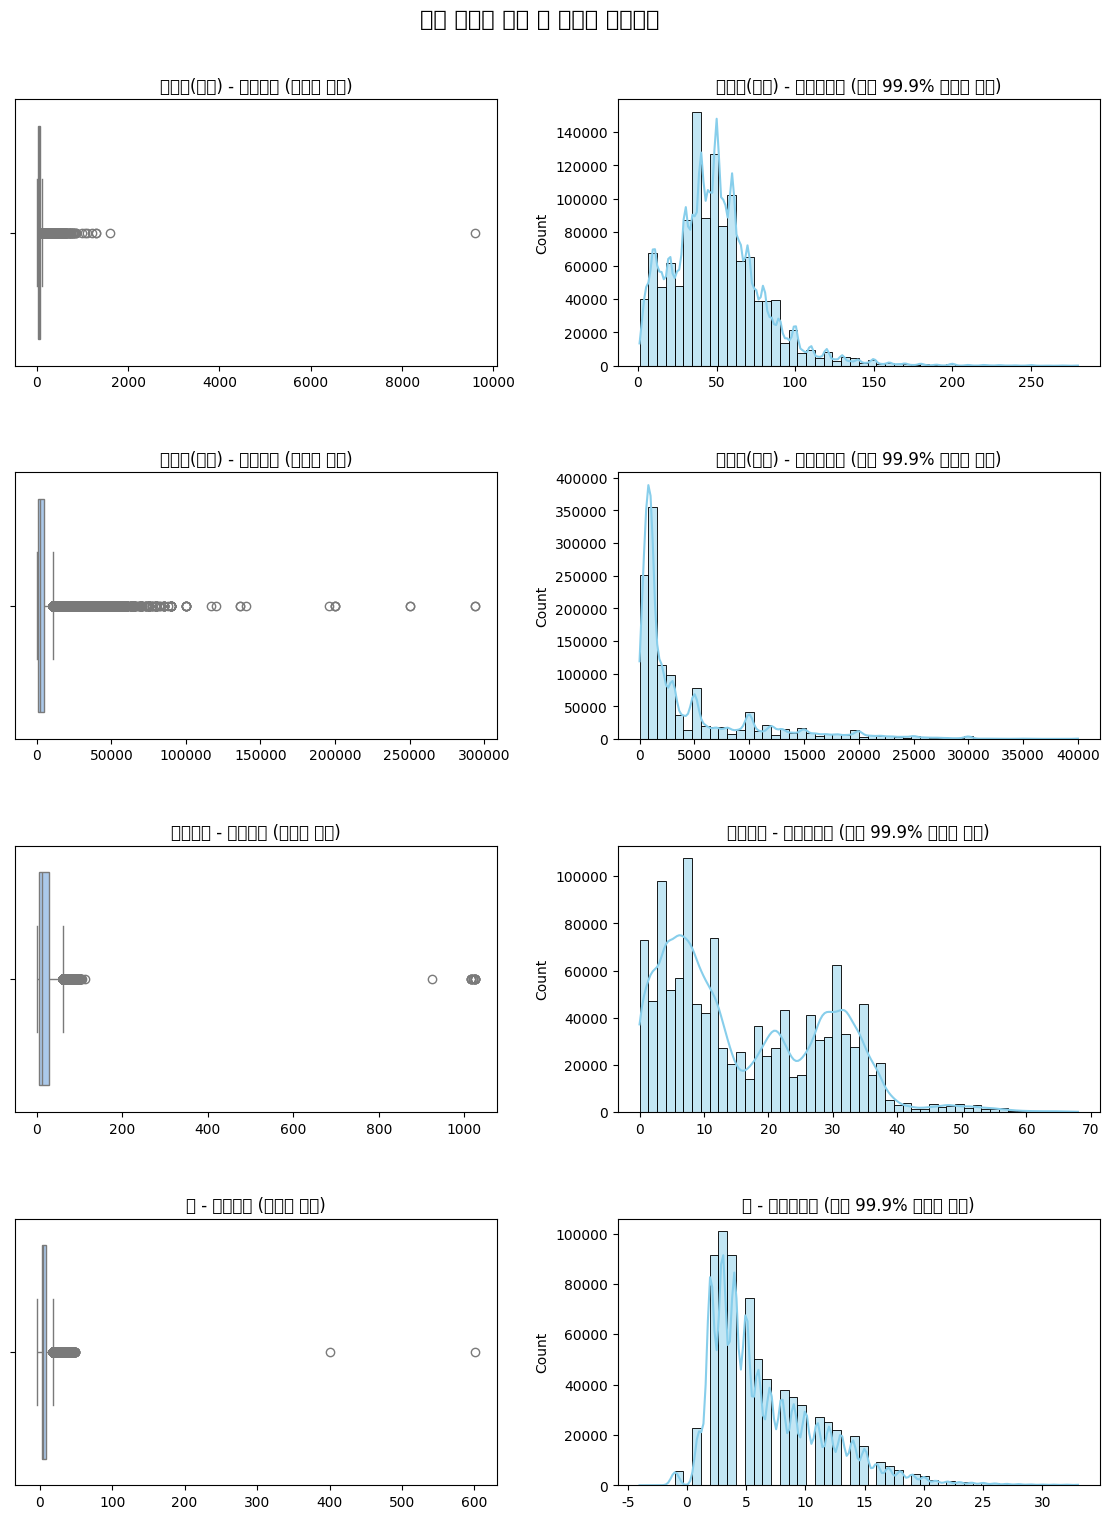

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 및 마이너스 깨짐 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 분석할 핵심 변수 지정
target_cols = ['임대료(만원)', '보증금(만원)', '건물나이', '층']

# ========================================================
# [STEP 1] 분위수(Quantiles) 상세 출력
# ========================================================
print("==================== 변수별 상세 분위수 (상위 구간) ====================")
quantiles_df = df[target_cols].quantile([0.5, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9999])
print(quantiles_df.to_string(formatters={col: '{:,.1f}'.format for col in target_cols}))
print("=" * 73)

# 최소값 및 최대값 추가 확인
print("\n[참고] 최소값 / 최대값 범위")
for col in target_cols:
    print(f" - {col}: 최소 {df[col].min():,} / 최대 {df[col].max():,}")


# ========================================================
# [STEP 2] 분포 시각화 (Boxplot & Histogram)
# ========================================================
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.25)

for i, col in enumerate(target_cols):
    # 왼쪽: Boxplot (이상치가 얼마나 튀어있는지 확인용)
    sns.boxplot(x=df[col], ax=axes[i, 0], palette='pastel')
    axes[i, 0].set_title(f'{col} - 박스플롯 (이상치 확인)', fontsize=12)
    axes[i, 0].set_xlabel('')

    # 오른쪽: 히스토그램 (전반적인 분포의 모양 확인용)
    # 지나치게 큰 이상치 때문에 그래프가 뭉개지는 것을 방지하기 위해 상위 99.9%까지만 플롯팅
    upper_limit = df[col].quantile(0.999)
    sns.histplot(df[df[col] <= upper_limit][col], ax=axes[i, 1], bins=50, kde=True, color='skyblue')
    axes[i, 1].set_title(f'{col} - 히스토그램 (상위 99.9% 컷오프 분포)', fontsize=12)
    axes[i, 1].set_xlabel('')

plt.suptitle('핵심 변수별 분포 및 이상치 스크리닝', fontsize=16, fontweight='bold', y=0.93)
plt.show()

In [17]:
# 1. 임대료
# 보수적으로 600만원 이하 적용
df = df[
    (df['임대료(만원)'].isna()) |
    ((df['임대료(만원)'] > 0) & (df['임대료(만원)'] <= 600))
].copy()

# 2. 보증금
df = df[
    (df['보증금(만원)'].isna()) |
    ((df['보증금(만원)'] > 0) & (df['보증금(만원)'] < 100000))
].copy()

# 3. 층
# 50㎡ 미만 소형 주거 분석이므로 -2~69 사용
df = df[
    (df['층'].isna()) |
    ((df['층'] >= -2) & (df['층'] <= 69))
].copy()

# 4. 건물나이
df = df[
    (df['건물나이'].isna()) |
    ((df['건물나이'] >= 0) & (df['건물나이'] <= 96))
].copy()

# 5. 건축년도
# 너무 오래되거나 미래인 건축년도 제거
df = df[
    (df['건축년도'].isna()) |
    (
        (df['건축년도'] >= 1930) &
        (df['건축년도'] <= df['계약연도'])
    )
].copy()

# 6. 계약기간
# NaN은 유지하고, 값이 있는 경우에만 1~60개월 조건 적용
if '계약기간_개월' in df.columns:
    df = df[
        (df['계약기간_개월'].isna()) |
        (
            (df['계약기간_개월'] > 0) &
            (df['계약기간_개월'] <= 60)
        )
    ].copy()

# 7. 종전보증금, 종전임대료
# NaN은 유지하고, 값이 있는 경우에만 0 이상 조건 적용
for col in ['종전보증금', '종전임대료']:
    if col in df.columns:
        df = df[
            (df[col].isna()) |
            (df[col] >= 0)
        ].copy()

print("이상치 제거 후:", df.shape)

이상치 제거 후: (1242901, 35)


## 16. 추가 파생변수 생성

In [18]:
# 확인할 파생 컬럼 목록
check_cols = [
    '계약월','법정동코드','임대료(만원)', '평당가격','자치구코드','건물용도','평수', '보증금(만원)'
]

# 실제 df에 존재하는 컬럼만 선택
check_cols = [col for col in check_cols if col in df.columns]

# 결측치 개수, 비율 확인
missing_check = pd.DataFrame({
    '결측치개수': df[check_cols].isna().sum(),
    '결측치비율(%)': df[check_cols].isna().mean() * 100
}).sort_values('결측치비율(%)', ascending=False)

missing_check

,결측치개수,결측치비율(%)
보증금(만원),3034,0.244106
평당가격,218,0.017540
임대료(만원),218,0.017540
법정동코드,0,0.000000
계약월,0,0.000000
자치구코드,0,0.000000
건물용도,0,0.000000
평수,0,0.000000


In [19]:
# 성수기 여부: 1, 2, 7, 8월
df['is_성수기'] = np.where(
    df['계약월'].isna(),
    np.nan,
    df['계약월'].isin([1, 2, 7, 8]).astype(int)
)

# 법정동별 월세 중앙값
dong_rent_median = df.groupby('법정동코드')['임대료(만원)'].median()
df['법정동_월세_중앙값'] = df['법정동코드'].map(dong_rent_median)

# 법정동별 평당가격 중앙값
dong_price_median = df.groupby('법정동코드')['평당가격'].median()
df['법정동_평당가격_중앙값'] = df['법정동코드'].map(dong_price_median)

# 자치구별 월세 중앙값
gu_rent_median = df.groupby('자치구코드')['임대료(만원)'].median()
df['자치구_월세_중앙값'] = df['자치구코드'].map(gu_rent_median)

# 용도별 평균 평수 대비 크기
if '건물용도' in df.columns:
    type_area_median = df.groupby('건물용도')['평수'].transform('median')
    df['용도별_평균대비_평수비율'] = df['평수'] / (type_area_median + 0.001)

# 보증금 대비 월세 비율
df['보증금대비월세비율'] = np.where(
    df['임대료(만원)'].isna() |
    df['보증금(만원)'].isna() |
    (df['보증금(만원)'] <= 0),
    np.nan,
    df['임대료(만원)'] / df['보증금(만원)']
)

df.head()

,접수년도,자치구코드,자치구명,법정동코드,법정동명,층,계약일,전월세구분,임대면적,보증금(만원),...,지하여부,신규계약여부_결측여부,종전보증금_결측여부,종전임대료_결측여부,is_성수기,법정동_월세_중앙값,법정동_평당가격_중앙값,자치구_월세_중앙값,용도별_평균대비_평수비율,보증금대비월세비율
0,2021,11170.0,용산구,11300.0,원효로2가,6.0,20210317,월세,21.45,500.0,...,0.0,1,1,1,0.0,40.0,4.551724,52.0,0.940653,0.066000
2,2021,11440.0,마포구,11000.0,노고산동,5.0,20201202,월세,33.66,10000.0,...,0.0,1,1,1,0.0,42.0,5.500000,55.0,1.476102,0.005500
4,2021,11545.0,금천구,10200.0,독산동,2.0,20210302,월세,17.67,500.0,...,0.0,1,1,1,0.0,45.0,6.235425,42.0,0.774888,0.100000
10,2021,11545.0,금천구,10200.0,독산동,4.0,20210805,월세,15.75,6000.0,...,0.0,1,1,1,1.0,45.0,6.235425,42.0,0.690690,0.001667
13,2021,11545.0,금천구,10200.0,독산동,5.0,20211002,월세,15.75,6300.0,...,0.0,0,0,0,0.0,45.0,6.235425,42.0,0.690690,0.002381


## 17. 갱신계약 증감 변수 생성
종전보증금/종전임대료가 실제로 있는 경우만 계산

In [20]:
df['보증금증감액'] = np.nan
df['임대료증감액'] = np.nan
df['보증금증감률(%)'] = np.nan
df['임대료증감률(%)'] = np.nan

renew_mask = (
    (df['종전보증금'] > 0) &
    (df['종전임대료'] > 0)
)

df.loc[renew_mask, '보증금증감액'] = (
    df.loc[renew_mask, '보증금(만원)'] - df.loc[renew_mask, '종전보증금']
)

df.loc[renew_mask, '임대료증감액'] = (
    df.loc[renew_mask, '임대료(만원)'] - df.loc[renew_mask, '종전임대료']
)

df.loc[renew_mask, '보증금증감률(%)'] = (
    df.loc[renew_mask, '보증금증감액'] / df.loc[renew_mask, '종전보증금'] * 100
)

df.loc[renew_mask, '임대료증감률(%)'] = (
    df.loc[renew_mask, '임대료증감액'] / df.loc[renew_mask, '종전임대료'] * 100
)

df[['보증금증감액', '임대료증감액', '보증금증감률(%)', '임대료증감률(%)']].head()

,보증금증감액,임대료증감액,보증금증감률(%),임대료증감률(%)
0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN
13,NaN,NaN,NaN,NaN


## 18. 변화 유형 변수 생성

In [21]:
def change_type(x):
    if pd.isna(x):
        return '해당없음'
    elif x > 0:
        return '상승'
    elif x < 0:
        return '하락'
    else:
        return '동결'

df['보증금변화'] = df['보증금증감액'].apply(change_type)
df['임대료변화'] = df['임대료증감액'].apply(change_type)

df[['보증금변화', '임대료변화']].head()

,보증금변화,임대료변화
0,해당없음,해당없음
2,해당없음,해당없음
4,해당없음,해당없음
10,해당없음,해당없음
13,해당없음,해당없음


In [22]:
missing_summary = pd.DataFrame({
    '결측치개수': df.isnull().sum(),
    '결측치비율(%)': df.isnull().mean() * 100
}).sort_values('결측치비율(%)', ascending=False)

missing_summary.head(30)

,결측치개수,결측치비율(%)
갱신청구권사용여부,1209112,97.281441
보증금증감률(%),1120158,90.124475
보증금증감액,1120158,90.124475
임대료증감액,1120110,90.120613
임대료증감률(%),1120110,90.120613
종전임대료,808836,65.076462
종전보증금,808759,65.070267
지하여부,508118,40.881615
층,508118,40.881615
신규계약여부,234598,18.875035


# 추천시스템

## 0. 라이브러리 불러오기

In [23]:
!apt-get update -qq
!apt-get install -y fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 124 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (29.1 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [24]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.2 MB/s eta 0:00:00


In [25]:
import os
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ==========================================
# Streamlit용 한글 폰트 설정
# ==========================================
FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if not os.path.exists(FONT_PATH):
    st.error(
        'NanumGothic 폰트 파일을 찾을 수 없습니다. '
        '코랩에서 fonts-nanum을 먼저 설치하세요.'
    )
    st.stop()

# 현재 Streamlit 프로세스의 Matplotlib에 폰트 직접 등록
fm.fontManager.addfont(FONT_PATH)

KOREAN_FONT = fm.FontProperties(
    fname=FONT_PATH
)

plt.rcParams.update({
    'font.family': KOREAN_FONT.get_name(),
    'axes.unicode_minus': False
})

## 1. 추천에 필요한 컬럼 확인

In [26]:
required_columns = [
    '계약연도',
    '자치구명',
    '법정동명',
    '보증금(만원)',
    '임대료(만원)',
    '평당가격',
    '평수',
    '건물나이'
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"추천에 필요한 컬럼이 없습니다: {missing_columns}"
    )

print("추천시스템에 필요한 기본 컬럼이 모두 존재합니다.")

추천시스템에 필요한 기본 컬럼이 모두 존재합니다.


In [27]:
optional_columns = [
    '지하여부',
    '건물용도'
]

for col in optional_columns:
    if col in df.columns:
        print(f"{col}: 사용 가능")
    else:
        print(f"{col}: 데이터에 없음")

지하여부: 사용 가능
건물용도: 사용 가능


## 2. 2021~2025년 추천용 데이터 생성

In [28]:
recommend_df = df[
    df['계약연도'].between(2021, 2025)
].copy()

recommend_df = recommend_df.dropna(
    subset=[
        '자치구명',
        '법정동명',
        '보증금(만원)',
        '평당가격',
        '평수'
    ]
).copy()

# 숫자형 변환
numeric_columns = [
    '보증금(만원)',
    '임대료(만원)',
    '평당가격',
    '평수',
    '건물나이'
]

for col in numeric_columns:
    if col in recommend_df.columns:
        recommend_df[col] = pd.to_numeric(
            recommend_df[col],
            errors='coerce'
        )

# 추천에 직접 필요한 수치가 변환 과정에서 NaN이 된 행 제거
recommend_df = recommend_df.dropna(
    subset=[
        '보증금(만원)',
        '평당가격',
        '평수'
    ]
)

# 잘못된 값 제거
recommend_df = recommend_df[
    (recommend_df['보증금(만원)'] >= 0) &
    (recommend_df['평당가격'] > 0) &
    (recommend_df['평수'] > 0)
].copy()

print("추천용 데이터 크기:", recommend_df.shape)
print(
    "추천용 데이터 기간:",
    recommend_df['계약연도'].min(),
    "~",
    recommend_df['계약연도'].max()
)

추천용 데이터 크기: (1216607, 47)
추천용 데이터 기간: 2021 ~ 2025


In [29]:
recommend_df[
    [
        '보증금(만원)',
        '임대료(만원)',
        '평당가격',
        '평수',
        '건물나이'
    ]
].describe().round(2)

,보증금(만원),임대료(만원),평당가격,평수,건물나이
count,1216607.00,1216607.00,1216607.00,1216607.00,1164882.0
mean,4597.28,50.89,6.66,8.56,16.56
std,6258.52,31.38,4.22,3.13,12.67
min,1.00,1.00,0.07,2.18,0.0
25%,1000.00,30.00,3.44,5.87,6.0
50%,2000.00,50.00,6.19,8.13,12.0
75%,5000.00,65.00,9.17,10.98,28.0
max,90000.00,600.00,101.07,15.15,95.0


## 3. 점수 계산용 함수

In [30]:
def minmax_score(series, reverse=False):
    """
    값을 0~1 사이 점수로 변환합니다.

    reverse=False:
        값이 클수록 높은 점수

    reverse=True:
        값이 작을수록 높은 점수
    """
    series = pd.to_numeric(
        series,
        errors='coerce'
    )

    if series.notna().sum() == 0:
        return pd.Series(
            0.5,
            index=series.index
        )

    fill_value = series.median()
    series = series.fillna(fill_value)

    min_value = series.min()
    max_value = series.max()

    if min_value == max_value:
        score = pd.Series(
            1.0,
            index=series.index
        )
    else:
        score = (
            series - min_value
        ) / (
            max_value - min_value
        )

    if reverse:
        score = 1 - score

    return score

## 4. 사용자 조건에 맞는 거래 필터링 함수

In [31]:
def filter_houses(
    data,
    deposit_min,
    deposit_max,
    price_per_pyeong_min,
    price_per_pyeong_max,
    area_min,
    area_max,
    exclude_basement=False,
    building_types=None
):
    """
    사용자가 설정한 조건을 만족하는 개별 거래를 필터링합니다.
    """

    # 입력값 검증
    if deposit_min > deposit_max:
        raise ValueError(
            "최소 보증금은 최대 보증금보다 작아야 합니다."
        )

    if price_per_pyeong_min > price_per_pyeong_max:
        raise ValueError(
            "최소 평당가격은 최대 평당가격보다 작아야 합니다."
        )

    if area_min > area_max:
        raise ValueError(
            "최소 평수는 최대 평수보다 작아야 합니다."
        )

    filtered = data[
        data['보증금(만원)'].between(
            deposit_min,
            deposit_max
        ) &
        data['평당가격'].between(
            price_per_pyeong_min,
            price_per_pyeong_max
        ) &
        data['평수'].between(
            area_min,
            area_max
        )
    ].copy()

    # 지하 제외
    if (
        exclude_basement and
        '지하여부' in filtered.columns
    ):
        # 지하여부 결측치는 지하라고 단정하지 않고 유지
        filtered = filtered[
            filtered['지하여부'].isna() |
            (filtered['지하여부'] == 0)
        ].copy()

    # 건물용도 선택
    if (
        building_types is not None and
        len(building_types) > 0 and
        '건물용도' in filtered.columns
    ):
        filtered = filtered[
            filtered['건물용도'].isin(building_types)
        ].copy()

    return filtered

## 5. 법정동별 집계 함수
개별 거래를 법정동별로 묶어 다음 내용을 계산함
- 조건 충족 거래 수
- 보증금 중앙값
- 평당가격 중앙값
- 월세 중앙값
- 평수 중앙값
- 건물나이 중앙값
- 최근 거래 연도 수
- 연도별 거래 지속성

In [32]:
def aggregate_by_region(filtered_data):
    """
    조건을 만족하는 거래를 법정동별로 집계합니다.
    """

    if filtered_data.empty:
        return pd.DataFrame()

    region_summary = (
        filtered_data
        .groupby(
            ['자치구명', '법정동명'],
            as_index=False
        )
        .agg(
            조건충족_거래수=(
                '법정동명',
                'size'
            ),
            보증금_중앙값=(
                '보증금(만원)',
                'median'
            ),
            보증금_최솟값=(
                '보증금(만원)',
                'min'
            ),
            보증금_최댓값=(
                '보증금(만원)',
                'max'
            ),
            평당가격_중앙값=(
                '평당가격',
                'median'
            ),
            평당가격_평균=(
                '평당가격',
                'mean'
            ),
            평당가격_표준편차=(
                '평당가격',
                'std'
            ),
            월세_중앙값=(
                '임대료(만원)',
                'median'
            ),
            평수_중앙값=(
                '평수',
                'median'
            ),
            건물나이_중앙값=(
                '건물나이',
                'median'
            ),
            거래연도수=(
                '계약연도',
                'nunique'
            ),
            최근거래연도=(
                '계약연도',
                'max'
            )
        )
    )

    # 가격 변동계수
    region_summary['가격변동계수'] = (
        region_summary['평당가격_표준편차'] /
        region_summary['평당가격_평균']
    )

    region_summary['가격변동계수'] = (
        region_summary['가격변동계수']
        .replace([np.inf, -np.inf], np.nan)
    )

    return region_summary

## 6. 전체 거래 대비 조건 적합률 계산
조건 충족 거래 수만 사용하면 거래량이 많은 지역이 항상 유리해질 수 있으므 해당 지역의 전체 거래 중 사용자 조건을 만족하는 비율도 계산함

In [33]:
def add_fit_rate(
    region_summary,
    filtered_data,
    full_data
):
    """
    법정동별 전체 거래 중 사용자 조건을 만족하는 비율을 계산합니다.
    """

    if region_summary.empty:
        return region_summary

    # 전체 데이터의 지역별 거래 수
    total_counts = (
        full_data
        .groupby(
            ['자치구명', '법정동명']
        )
        .size()
        .reset_index(name='지역전체_거래수')
    )

    result = region_summary.merge(
        total_counts,
        on=['자치구명', '법정동명'],
        how='left'
    )

    result['조건적합률'] = (
        result['조건충족_거래수'] /
        result['지역전체_거래수']
    )

    return result

## 7. 추천 점수 계산

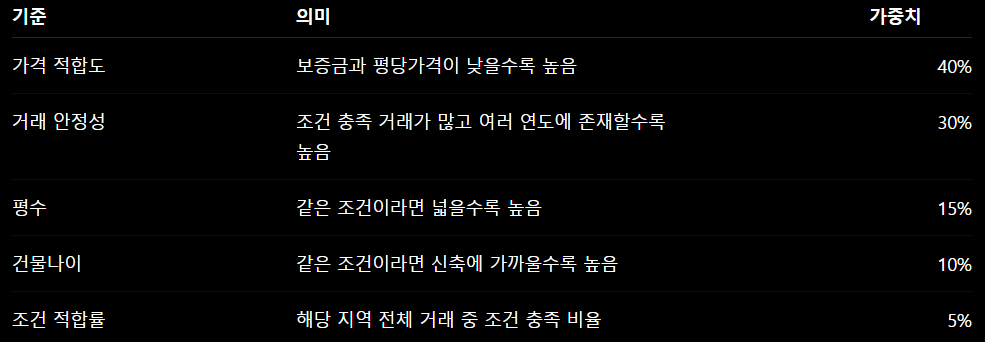

- 가격 적합도 40%: 보증금 20%, 평당가격 20%

In [34]:
def calculate_recommendation_score(
    region_summary,
    min_transactions=3
):
    """
    법정동별 추천 점수를 계산합니다.
    """

    if region_summary.empty:
        return region_summary

    result = region_summary.copy()

    # 거래가 지나치게 적은 지역 제외
    result = result[
        result['조건충족_거래수'] >= min_transactions
    ].copy()

    if result.empty:
        return result

    # 1. 보증금 점수: 낮을수록 좋음
    result['보증금점수'] = minmax_score(
        result['보증금_중앙값'],
        reverse=True
    )

    # 2. 평당가격 점수: 낮을수록 좋음
    result['평당가격점수'] = minmax_score(
        result['평당가격_중앙값'],
        reverse=True
    )

    # 3. 거래량 점수: 많을수록 좋음
    # 큰 지역의 거래 수가 점수를 지나치게 지배하지 않도록 log 사용
    result['거래량점수'] = minmax_score(
        np.log1p(result['조건충족_거래수'])
    )

    # 4. 거래 지속성: 2023~2025년 여러 연도에 거래가 있을수록 좋음
    result['거래지속성점수'] = (
        result['거래연도수']
        .clip(lower=1, upper=3) / 3
    )

    # 5. 가격 안정성: 변동계수가 작을수록 좋음
    result['가격안정성점수'] = minmax_score(
        result['가격변동계수'],
        reverse=True
    )

    # 변동계수를 계산할 수 없는 경우 중립점수
    result['가격안정성점수'] = (
        result['가격안정성점수']
        .fillna(0.5)
    )

    # 6. 평수: 넓을수록 좋음
    result['평수점수'] = minmax_score(
        result['평수_중앙값']
    )

    # 7. 건물나이: 작을수록 좋음
    result['건물상태점수'] = minmax_score(
        result['건물나이_중앙값'],
        reverse=True
    )

    # 건물나이 결측치는 중립점수
    result['건물상태점수'] = (
        result['건물상태점수']
        .fillna(0.5)
    )

    # 8. 조건 적합률: 높을수록 좋음
    result['조건적합률점수'] = minmax_score(
        result['조건적합률']
    )

    # 거래 안정성 통합
    result['거래안정성점수'] = (
        result['거래량점수'] * 0.50 +
        result['거래지속성점수'] * 0.30 +
        result['가격안정성점수'] * 0.20
    )

    # 최종 추천 점수
    result['추천점수'] = (
        result['보증금점수'] * 0.20 +
        result['평당가격점수'] * 0.20 +
        result['거래안정성점수'] * 0.30 +
        result['평수점수'] * 0.15 +
        result['건물상태점수'] * 0.10 +
        result['조건적합률점수'] * 0.05
    ) * 100

    # 지역명 생성
    result['추천지역'] = (
        result['자치구명'].astype(str) +
        ' ' +
        result['법정동명'].astype(str)
    )

    result = result.sort_values(
        by=[
            '추천점수',
            '조건충족_거래수'
        ],
        ascending=[False, False]
    ).reset_index(drop=True)

    result['추천순위'] = (
        np.arange(1, len(result) + 1)
    )

    return result

## 8. 조건 완화 함수
- 정확한 조건에서 결과가 없으면 다음 순서로 완화함
  + 1차: 10% 완화
  + 2차: 20% 완화
  + 3차: 30% 완화
- 최소값은 낮추고 최대값은 높임

In [35]:
def get_relaxed_conditions(
    deposit_min,
    deposit_max,
    price_min,
    price_max,
    area_min,
    area_max,
    relaxation_rate
):
    """
    조건을 지정된 비율만큼 완화합니다.
    """

    relaxed_conditions = {
        'deposit_min': max(
            0,
            deposit_min * (1 - relaxation_rate)
        ),
        'deposit_max': (
            deposit_max * (1 + relaxation_rate)
        ),
        'price_min': max(
            0,
            price_min * (1 - relaxation_rate)
        ),
        'price_max': (
            price_max * (1 + relaxation_rate)
        ),
        'area_min': max(
            0,
            area_min * (1 - relaxation_rate)
        ),
        'area_max': (
            area_max * (1 + relaxation_rate)
        )
    }

    return relaxed_conditions

## 9. 전체 추천 함수
필터링, 법정동별 집계, 적합률 계산, 점수 계산, 조건 완화를 하나로 합침

In [36]:
def recommend_regions(
    data,
    deposit_min,
    deposit_max,
    price_min,
    price_max,
    area_min,
    area_max,
    exclude_basement=False,
    building_types=None,
    min_transactions=3,
    top_n=15,
    use_relaxation=True
):
    """
    사용자 조건에 따른 법정동 추천 결과를 반환합니다.
    """

    # 완화하지 않은 조건부터 최대 30% 완화까지
    if use_relaxation:
        relaxation_rates = [0.0, 0.1, 0.2, 0.3]
    else:
        relaxation_rates = [0.0]

    for rate in relaxation_rates:

        conditions = get_relaxed_conditions(
            deposit_min=deposit_min,
            deposit_max=deposit_max,
            price_min=price_min,
            price_max=price_max,
            area_min=area_min,
            area_max=area_max,
            relaxation_rate=rate
        )

        # 개별 거래 필터링
        filtered = filter_houses(
            data=data,
            deposit_min=conditions['deposit_min'],
            deposit_max=conditions['deposit_max'],
            price_per_pyeong_min=conditions['price_min'],
            price_per_pyeong_max=conditions['price_max'],
            area_min=conditions['area_min'],
            area_max=conditions['area_max'],
            exclude_basement=exclude_basement,
            building_types=building_types
        )

        if filtered.empty:
            continue

        # 법정동별 집계
        region_summary = aggregate_by_region(
            filtered
        )

        # 조건 적합률 추가
        region_summary = add_fit_rate(
            region_summary=region_summary,
            filtered_data=filtered,
            full_data=data
        )

        # 추천 점수 계산
        scored_regions = calculate_recommendation_score(
            region_summary=region_summary,
            min_transactions=min_transactions
        )

        if scored_regions.empty:
            continue

        top_regions = scored_regions.head(
            top_n
        ).copy()

        return {
            'regions': top_regions,
            'all_scored_regions': scored_regions,
            'matched_houses': filtered,
            'relaxation_rate': rate,
            'conditions': conditions
        }

    # 30%까지 완화해도 결과가 없는 경우
    return {
        'regions': pd.DataFrame(),
        'all_scored_regions': pd.DataFrame(),
        'matched_houses': pd.DataFrame(),
        'relaxation_rate': None,
        'conditions': None
    }

## 10. 추천함수 실행

In [37]:
result = recommend_regions(
    data=recommend_df,
    deposit_min=500,
    deposit_max=5000,
    price_min=2,
    price_max=8,
    area_min=5,
    area_max=12,
    exclude_basement=True,
    building_types=None,
    min_transactions=5,
    top_n=15,
    use_relaxation=True
)

In [38]:
recommended_regions = result['regions']
matched_houses = result['matched_houses']
relaxation_rate = result['relaxation_rate']

if recommended_regions.empty:
    print("30%까지 조건을 완화했지만 추천 가능한 지역이 없습니다.")

else:
    if relaxation_rate == 0:
        print("입력한 조건을 그대로 적용했습니다.")
    else:
        print(
            f"조건을 {int(relaxation_rate * 100)}% "
            "완화한 추천 결과입니다."
        )

    print(
        "조건을 만족하는 전체 거래 수:",
        f"{len(matched_houses):,}건"
    )

    display_columns = [
        '추천순위',
        '추천지역',
        '추천점수',
        '조건충족_거래수',
        '지역전체_거래수',
        '조건적합률',
        '보증금_중앙값',
        '평당가격_중앙값',
        '월세_중앙값',
        '평수_중앙값',
        '건물나이_중앙값',
        '거래연도수'
    ]

    display(
        recommended_regions[
            display_columns
        ].round(2)
    )

입력한 조건을 그대로 적용했습니다.
조건을 만족하는 전체 거래 수: 293,690건


,추천순위,추천지역,추천점수,조건충족_거래수,지역전체_거래수,조건적합률,보증금_중앙값,평당가격_중앙값,월세_중앙값,평수_중앙값,건물나이_중앙값,거래연도수
0,1,도봉구 방학동,73.01,1745,4860,0.36,500.0,4.50,40.0,9.73,26.0,5
1,2,강동구 강일동,72.74,771,7849,0.10,1000.0,2.75,28.0,8.87,5.0,5
2,3,은평구 불광동,71.66,2156,6165,0.35,1000.0,4.28,40.0,9.82,28.0,5
3,4,성북구 길음동,70.87,282,1514,0.19,1500.0,2.78,27.0,10.00,15.0,5
4,5,양천구 신월동,70.74,2123,6887,0.31,1000.0,4.38,40.0,9.75,31.0,5
5,6,중랑구 면목동,70.16,6120,15541,0.39,1000.0,4.95,40.0,9.09,30.0,5
6,7,도봉구 창동,70.13,3344,8333,0.40,1000.0,5.48,50.0,10.00,28.0,5
7,8,송파구 마천동,70.03,1051,3563,0.29,1000.0,3.87,35.0,9.33,32.0,5
8,9,금천구 시흥동,69.81,2591,7435,0.35,1000.0,4.37,40.0,9.09,31.0,5
9,10,강북구 미아동,69.27,2745,9529,0.29,1000.0,4.49,40.0,9.09,29.0,5


## 11. 사용자 입력으로 추천 실행하기

In [39]:
deposit_min = float(
    input("최소 보증금(만원)을 입력하세요: ")
)

deposit_max = float(
    input("최대 보증금(만원)을 입력하세요: ")
)

price_min = float(
    input("최소 평당 임대료(만원/평)를 입력하세요: ")
)

price_max = float(
    input("최대 평당 임대료(만원/평)를 입력하세요: ")
)

area_min = float(
    input("최소 평수(평)를 입력하세요: ")
)

area_max = float(
    input("최대 평수(평)를 입력하세요: ")
)

basement_answer = input(
    "지하를 제외하시겠습니까? (y/n): "
).strip().lower()

exclude_basement = (
    basement_answer == 'y'
)

result = recommend_regions(
    data=recommend_df,
    deposit_min=deposit_min,
    deposit_max=deposit_max,
    price_min=price_min,
    price_max=price_max,
    area_min=area_min,
    area_max=area_max,
    exclude_basement=exclude_basement,
    min_transactions=3,
    top_n=15,
    use_relaxation=True
)

KeyboardInterrupt: Interrupted by user

## 12. 추천 결과 막대그래프

### 12-1. 추천 점수

In [40]:
def plot_recommendation_score(
    recommended_regions
):
    if recommended_regions.empty:
        print("시각화할 추천 결과가 없습니다.")
        return

    plot_df = (
        recommended_regions
        .sort_values(
            '추천점수',
            ascending=True
        )
        .copy()
    )

    plt.figure(figsize=(11, 7))

    bars = plt.barh(
        plot_df['추천지역'],
        plot_df['추천점수']
    )

    for bar, value in zip(
        bars,
        plot_df['추천점수']
    ):
        plt.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}점',
            va='center'
        )

    plt.title(
        '사용자 조건 기반 추천 지역 순위',
        fontsize=15
    )
    plt.xlabel('추천 점수')
    plt.ylabel('추천 지역')
    plt.xlim(
        0,
        max(105, plot_df['추천점수'].max() + 8)
    )
    plt.tight_layout()
    plt.show()

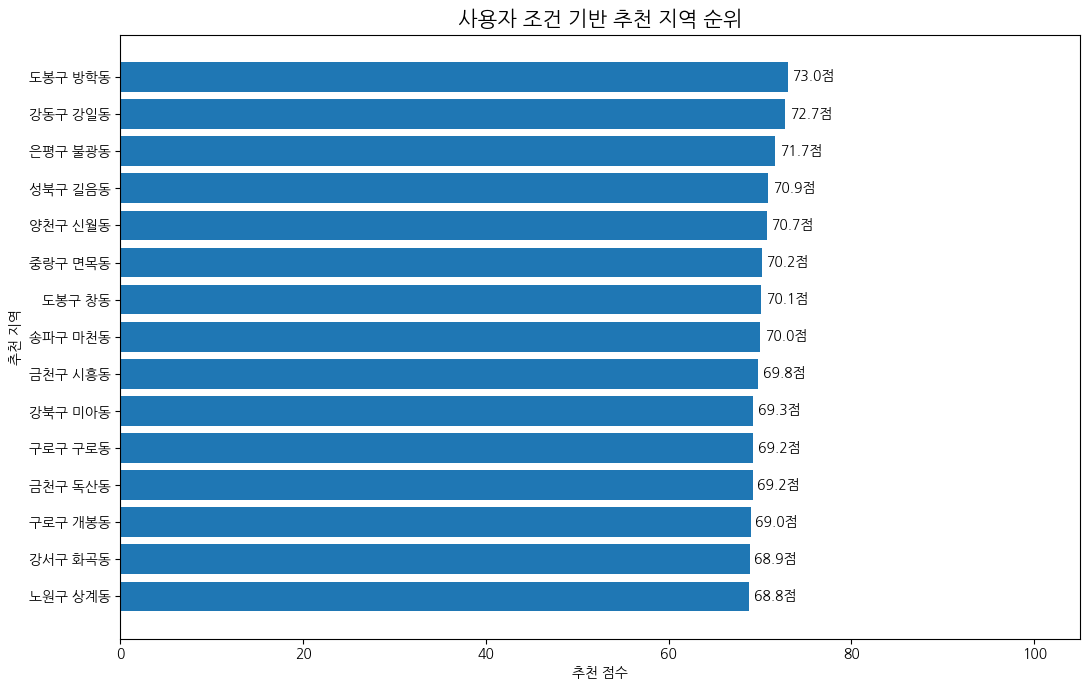

In [41]:
plot_recommendation_score(
    result['regions']
)

### 12-2. 조건을 만족하는 거래 수

In [42]:
def plot_matched_transaction_count(
    recommended_regions
):
    if recommended_regions.empty:
        print("시각화할 추천 결과가 없습니다.")
        return

    plot_df = (
        recommended_regions
        .sort_values(
            '조건충족_거래수',
            ascending=True
        )
        .copy()
    )

    plt.figure(figsize=(11, 7))

    bars = plt.barh(
        plot_df['추천지역'],
        plot_df['조건충족_거래수']
    )

    for bar, value in zip(
        bars,
        plot_df['조건충족_거래수']
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {int(value):,}건',
            va='center'
        )

    plt.title(
        '추천 지역별 조건 충족 거래 수',
        fontsize=15
    )
    plt.xlabel('조건 충족 거래 수')
    plt.ylabel('추천 지역')
    plt.tight_layout()
    plt.show()

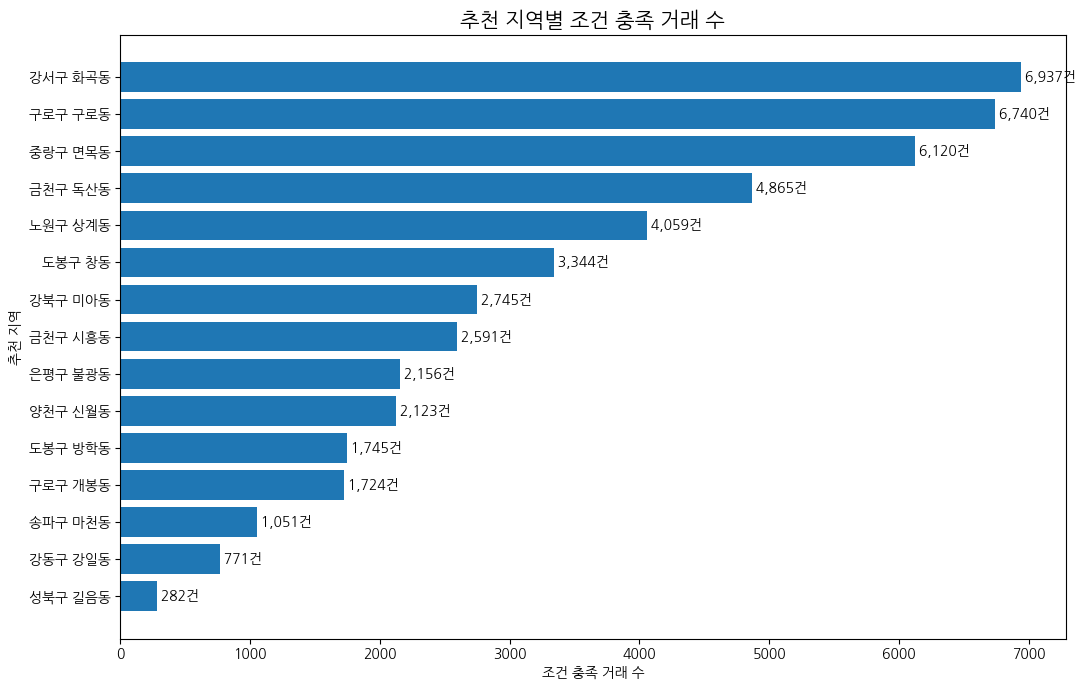

In [43]:
plot_matched_transaction_count(
    result['regions']
)

### 12-3. 추천 지역별 평당가격 중앙값

In [44]:
def plot_price_per_pyeong(
    recommended_regions
):
    if recommended_regions.empty:
        print("시각화할 추천 결과가 없습니다.")
        return

    plot_df = (
        recommended_regions
        .sort_values(
            '평당가격_중앙값',
            ascending=False
        )
        .copy()
    )

    plt.figure(figsize=(11, 7))

    bars = plt.barh(
        plot_df['추천지역'],
        plot_df['평당가격_중앙값']
    )

    for bar, value in zip(
        bars,
        plot_df['평당가격_중앙값']
    ):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f' {value:.1f}만원',
            va='center'
        )

    plt.title(
        '추천 지역별 평당 임대료 중앙값',
        fontsize=15
    )
    plt.xlabel('평당 임대료 중앙값(만원/평)')
    plt.ylabel('추천 지역')
    plt.tight_layout()
    plt.show()

## 13. 추천지역의 연도별 가격 추이

In [45]:
def plot_region_price_trend(
    full_data,
    region_row
):
    gu_name = region_row['자치구명']
    dong_name = region_row['법정동명']

    region_data = full_data[
        (full_data['자치구명'] == gu_name) &
        (full_data['법정동명'] == dong_name)
    ].copy()

    trend = (
        region_data
        .groupby(
            '계약연도',
            as_index=False
        )
        .agg(
            평당가격_중앙값=(
                '평당가격',
                'median'
            ),
            보증금_중앙값=(
                '보증금(만원)',
                'median'
            ),
            거래수=(
                '법정동명',
                'size'
            )
        )
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        trend['계약연도'],
        trend['평당가격_중앙값'],
        marker='o'
    )

    for x, y in zip(
        trend['계약연도'],
        trend['평당가격_중앙값']
    ):
        plt.text(
            x,
            y,
            f'{y:.1f}',
            ha='center',
            va='bottom'
        )

    plt.title(
        f'{gu_name} {dong_name} 연도별 평당 임대료'
    )
    plt.xlabel('계약연도')
    plt.ylabel('평당 임대료 중앙값(만원/평)')
    plt.xticks(trend['계약연도'])
    plt.tight_layout()
    plt.show()

## 14. 추천 이유 문장 생성

In [46]:
def make_recommendation_reason(row):
    reasons = []

    if row['보증금점수'] >= 0.7:
        reasons.append('보증금 부담이 비교적 낮음')

    if row['평당가격점수'] >= 0.7:
        reasons.append('평당 임대료가 비교적 낮음')

    if row['거래안정성점수'] >= 0.7:
        reasons.append('조건에 맞는 거래가 안정적으로 존재함')

    if row['평수점수'] >= 0.7:
        reasons.append('같은 조건에서 주거 면적이 넓은 편임')

    if row['건물상태점수'] >= 0.7:
        reasons.append('건물 연식이 비교적 최근임')

    if row['조건적합률점수'] >= 0.7:
        reasons.append('지역 내 조건 적합 매물 비율이 높음')

    if len(reasons) == 0:
        reasons.append('여러 조건을 종합했을 때 균형이 좋음')

    return ', '.join(reasons)

In [47]:
if not result['regions'].empty:
    result['regions']['추천이유'] = (
        result['regions']
        .apply(
            make_recommendation_reason,
            axis=1
        )
    )

    display(
        result['regions'][
            [
                '추천순위',
                '추천지역',
                '추천점수',
                '추천이유'
            ]
        ]
    )

,추천순위,추천지역,추천점수,추천이유
0,1,도봉구 방학동,73.014902,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
1,2,강동구 강일동,72.742014,"보증금 부담이 비교적 낮음, 평당 임대료가 비교적 낮음, 건물 연식이 비교적 최근임"
2,3,은평구 불광동,71.658542,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
3,4,성북구 길음동,70.86606,"보증금 부담이 비교적 낮음, 평당 임대료가 비교적 낮음, 건물 연식이 비교적 최근임"
4,5,양천구 신월동,70.736497,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
5,6,중랑구 면목동,70.162525,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
6,7,도봉구 창동,70.13219,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
7,8,송파구 마천동,70.02743,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
8,9,금천구 시흥동,69.807336,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"
9,10,강북구 미아동,69.270492,"보증금 부담이 비교적 낮음, 조건에 맞는 거래가 안정적으로 존재함"


## 15. 건물용도 선택 조건 추가

In [48]:
if '건물용도' in recommend_df.columns:
    print(
        recommend_df['건물용도']
        .value_counts(dropna=False)
    )

건물용도
단독다가구    491032
연립다세대    260057
오피스텔     255381
아파트      210137
Name: count, dtype: int64


In [49]:
selected_building_types = [
    '단독다가구',
    '오피스텔'
]

result = recommend_regions(
    data=recommend_df,
    deposit_min=500,
    deposit_max=5000,
    price_min=2,
    price_max=8,
    area_min=5,
    area_max=12,
    exclude_basement=True,
    building_types=selected_building_types,
    min_transactions=3,
    top_n=15,
    use_relaxation=True
)

## 16. 스트림릿 전용 데이터 저장

In [50]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
save_path = '/content/drive/MyDrive/부동산/recommend_data.parquet'

recommend_df.to_parquet(
    save_path,
    index=False
)

print(f'저장 완료: {save_path}')

저장 완료: /content/drive/MyDrive/부동산/recommend_data.parquet


In [52]:
recommend_df.to_parquet(
    'recommend_data.parquet',
    index=False
)

print("recommend_data.parquet 저장 완료")

recommend_data.parquet 저장 완료


## 17. 스트림릿 앱 코드

In [53]:
%%writefile /content/app.py

import os
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ==========================================
# 0. Streamlit용 한글 폰트 설정
# ==========================================
FONT_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)

    KOREAN_FONT = fm.FontProperties(
        fname=FONT_PATH
    )

    plt.rcParams['font.family'] = KOREAN_FONT.get_name()
    plt.rcParams['axes.unicode_minus'] = False

else:
    KOREAN_FONT = None


# ==========================================
# 1. 페이지 설정
# ==========================================
st.set_page_config(
    page_title='서울 월세 거주지역 추천',
    page_icon='🏠',
    layout='wide'
)

st.title('🏠 서울 월세 거주지역 추천시스템')

st.write(
    '2023~2025년 서울 월세 실거래 데이터를 바탕으로 '
    '보증금, 평당 임대료, 평수를 고려하여 '
    '거주 가능한 법정동을 추천합니다.'
)

if KOREAN_FONT is None:
    st.warning(
        '한글 폰트 파일을 찾지 못했습니다. '
        '코랩에서 fonts-nanum을 설치한 뒤 서버를 다시 실행하세요.'
    )


# ==========================================
# 2. 데이터 불러오기
# ==========================================
@st.cache_data
def load_data():
    data_path = '/content/recommend_data.parquet'

    if not os.path.exists(data_path):
        raise FileNotFoundError(
            f'데이터 파일이 없습니다: {data_path}'
        )

    data = pd.read_parquet(data_path)

    return data


try:
    df = load_data()

except Exception as error:
    st.error(f'데이터 불러오기 실패: {error}')
    st.stop()


# ==========================================
# 3. 점수 변환 함수
# ==========================================
def minmax_score(series, reverse=False):
    series = pd.to_numeric(
        series,
        errors='coerce'
    )

    if series.notna().sum() == 0:
        return pd.Series(
            0.5,
            index=series.index
        )

    series = series.fillna(
        series.median()
    )

    min_value = series.min()
    max_value = series.max()

    if min_value == max_value:
        score = pd.Series(
            1.0,
            index=series.index
        )

    else:
        score = (
            series - min_value
        ) / (
            max_value - min_value
        )

    if reverse:
        score = 1 - score

    return score


# ==========================================
# 4. 개별 거래 필터링
# ==========================================
def filter_houses(
    data,
    deposit_min,
    deposit_max,
    price_min,
    price_max,
    area_min,
    area_max,
    exclude_basement=False,
    building_types=None
):
    filtered = data[
        data['보증금(만원)'].between(
            deposit_min,
            deposit_max
        )
        &
        data['평당가격'].between(
            price_min,
            price_max
        )
        &
        data['평수'].between(
            area_min,
            area_max
        )
    ].copy()

    if (
        exclude_basement
        and '지하여부' in filtered.columns
    ):
        filtered = filtered[
            filtered['지하여부'].isna()
            |
            (filtered['지하여부'] == 0)
        ].copy()

    if (
        building_types is not None
        and len(building_types) > 0
        and '건물용도' in filtered.columns
    ):
        filtered = filtered[
            filtered['건물용도'].isin(
                building_types
            )
        ].copy()

    return filtered


# ==========================================
# 5. 법정동별 집계
# ==========================================
def aggregate_by_region(filtered):
    if filtered.empty:
        return pd.DataFrame()

    summary = (
        filtered
        .groupby(
            ['자치구명', '법정동명'],
            as_index=False
        )
        .agg(
            조건충족_거래수=(
                '법정동명',
                'size'
            ),
            보증금_중앙값=(
                '보증금(만원)',
                'median'
            ),
            평당가격_중앙값=(
                '평당가격',
                'median'
            ),
            평당가격_평균=(
                '평당가격',
                'mean'
            ),
            평당가격_표준편차=(
                '평당가격',
                'std'
            ),
            월세_중앙값=(
                '임대료(만원)',
                'median'
            ),
            평수_중앙값=(
                '평수',
                'median'
            ),
            건물나이_중앙값=(
                '건물나이',
                'median'
            ),
            거래연도수=(
                '계약연도',
                'nunique'
            )
        )
    )

    summary['가격변동계수'] = (
        summary['평당가격_표준편차']
        /
        summary['평당가격_평균']
    )

    summary['가격변동계수'] = (
        summary['가격변동계수']
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

    return summary


# ==========================================
# 6. 적합률 추가
# ==========================================
def add_fit_rate(summary, full_data):
    total_counts = (
        full_data
        .groupby(
            ['자치구명', '법정동명']
        )
        .size()
        .reset_index(
            name='지역전체_거래수'
        )
    )

    result = summary.merge(
        total_counts,
        on=['자치구명', '법정동명'],
        how='left'
    )

    result['조건적합률'] = (
        result['조건충족_거래수']
        /
        result['지역전체_거래수']
    )

    return result


# ==========================================
# 7. 추천 점수 계산
# ==========================================
def calculate_score(
    summary,
    min_transactions
):
    result = summary[
        summary['조건충족_거래수']
        >= min_transactions
    ].copy()

    if result.empty:
        return result

    result['보증금점수'] = minmax_score(
        result['보증금_중앙값'],
        reverse=True
    )

    result['평당가격점수'] = minmax_score(
        result['평당가격_중앙값'],
        reverse=True
    )

    result['거래량점수'] = minmax_score(
        np.log1p(
            result['조건충족_거래수']
        )
    )

    result['거래지속성점수'] = (
        result['거래연도수']
        .clip(lower=1, upper=3)
        / 3
    )

    result['가격안정성점수'] = (
        minmax_score(
            result['가격변동계수'],
            reverse=True
        )
        .fillna(0.5)
    )

    result['거래안정성점수'] = (
        result['거래량점수'] * 0.50
        +
        result['거래지속성점수'] * 0.30
        +
        result['가격안정성점수'] * 0.20
    )

    result['평수점수'] = minmax_score(
        result['평수_중앙값']
    )

    result['건물상태점수'] = (
        minmax_score(
            result['건물나이_중앙값'],
            reverse=True
        )
        .fillna(0.5)
    )

    result['조건적합률점수'] = minmax_score(
        result['조건적합률']
    )

    result['추천점수'] = (
        result['보증금점수'] * 0.20
        +
        result['평당가격점수'] * 0.20
        +
        result['거래안정성점수'] * 0.30
        +
        result['평수점수'] * 0.15
        +
        result['건물상태점수'] * 0.10
        +
        result['조건적합률점수'] * 0.05
    ) * 100

    result['추천지역'] = (
        result['자치구명'].astype(str)
        + ' '
        + result['법정동명'].astype(str)
    )

    result = (
        result
        .sort_values(
            by=[
                '추천점수',
                '조건충족_거래수'
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )

    result['추천순위'] = (
        np.arange(
            1,
            len(result) + 1
        )
    )

    return result


# ==========================================
# 8. 추천 이유 생성
# ==========================================
def make_reason(row):
    reasons = []

    if row['보증금점수'] >= 0.7:
        reasons.append(
            '보증금 부담이 낮은 편'
        )

    if row['평당가격점수'] >= 0.7:
        reasons.append(
            '평당 임대료가 낮은 편'
        )

    if row['거래안정성점수'] >= 0.7:
        reasons.append(
            '조건에 맞는 거래가 안정적으로 존재'
        )

    if row['평수점수'] >= 0.7:
        reasons.append(
            '상대적으로 넓은 주거 면적'
        )

    if row['건물상태점수'] >= 0.7:
        reasons.append(
            '건물 연식이 비교적 최근'
        )

    if not reasons:
        reasons.append(
            '가격과 거래 안정성의 균형이 좋음'
        )

    return ', '.join(reasons)


# ==========================================
# 9. 추천 실행
# ==========================================
def run_recommendation(
    data,
    deposit_min,
    deposit_max,
    price_min,
    price_max,
    area_min,
    area_max,
    exclude_basement,
    building_types,
    min_transactions,
    top_n
):
    relaxation_rates = [
        0.0,
        0.1,
        0.2,
        0.3
    ]

    for rate in relaxation_rates:
        filtered = filter_houses(
            data=data,
            deposit_min=max(
                0,
                deposit_min * (1 - rate)
            ),
            deposit_max=(
                deposit_max * (1 + rate)
            ),
            price_min=max(
                0,
                price_min * (1 - rate)
            ),
            price_max=(
                price_max * (1 + rate)
            ),
            area_min=max(
                0,
                area_min * (1 - rate)
            ),
            area_max=(
                area_max * (1 + rate)
            ),
            exclude_basement=exclude_basement,
            building_types=building_types
        )

        if filtered.empty:
            continue

        summary = aggregate_by_region(
            filtered
        )

        summary = add_fit_rate(
            summary,
            data
        )

        scored = calculate_score(
            summary,
            min_transactions
        )

        if not scored.empty:
            scored['추천이유'] = scored.apply(
                make_reason,
                axis=1
            )

            return (
                scored.head(top_n),
                filtered,
                rate
            )

    return (
        pd.DataFrame(),
        pd.DataFrame(),
        None
    )


# ==========================================
# 10. 사용자 입력
# ==========================================
st.sidebar.header(
    '희망 조건 입력'
)

deposit_min = st.sidebar.number_input(
    '최소 보증금(만원)',
    min_value=0,
    value=500,
    step=100
)

deposit_max = st.sidebar.number_input(
    '최대 보증금(만원)',
    min_value=0,
    value=5000,
    step=100
)

price_min = st.sidebar.number_input(
    '최소 평당 임대료(만원/평)',
    min_value=0.0,
    value=2.0,
    step=0.5
)

price_max = st.sidebar.number_input(
    '최대 평당 임대료(만원/평)',
    min_value=0.0,
    value=8.0,
    step=0.5
)

area_min = st.sidebar.number_input(
    '최소 평수',
    min_value=0.0,
    value=5.0,
    step=0.5
)

area_max = st.sidebar.number_input(
    '최대 평수',
    min_value=0.0,
    value=12.0,
    step=0.5
)

exclude_basement = st.sidebar.checkbox(
    '지하 매물 제외',
    value=True
)

min_transactions = st.sidebar.slider(
    '지역별 최소 거래 수',
    min_value=1,
    max_value=30,
    value=3
)

top_n = st.sidebar.slider(
    '추천 지역 수',
    min_value=5,
    max_value=20,
    value=10
)

if '건물용도' in df.columns:
    building_options = sorted(
        df['건물용도']
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    building_types = st.sidebar.multiselect(
        '건물용도 선택',
        options=building_options,
        default=[]
    )

else:
    building_types = None


# ==========================================
# 11. 추천 버튼
# ==========================================
if st.sidebar.button(
    '추천 지역 찾기',
    type='primary'
):
    if deposit_min > deposit_max:
        st.error(
            '최소 보증금은 최대 보증금보다 작아야 합니다.'
        )

    elif price_min > price_max:
        st.error(
            '최소 평당 임대료는 최대 평당 임대료보다 '
            '작아야 합니다.'
        )

    elif area_min > area_max:
        st.error(
            '최소 평수는 최대 평수보다 작아야 합니다.'
        )

    else:
        regions, matched, relaxation_rate = (
            run_recommendation(
                data=df,
                deposit_min=deposit_min,
                deposit_max=deposit_max,
                price_min=price_min,
                price_max=price_max,
                area_min=area_min,
                area_max=area_max,
                exclude_basement=exclude_basement,
                building_types=building_types,
                min_transactions=min_transactions,
                top_n=top_n
            )
        )

        if regions.empty:
            st.warning(
                '조건을 30%까지 완화했지만 '
                '추천 가능한 지역이 없습니다.'
            )

        else:
            if relaxation_rate == 0:
                st.success(
                    '입력 조건을 만족하는 지역을 찾았습니다.'
                )

            else:
                st.warning(
                    f'정확한 조건의 결과가 부족하여 '
                    f'조건을 {int(relaxation_rate * 100)}% '
                    '완화했습니다.'
                )

            # ==================================
            # 요약 지표
            # ==================================
            col1, col2, col3 = st.columns(3)

            col1.metric(
                '조건 충족 거래',
                f'{len(matched):,}건'
            )

            col2.metric(
                '추천 지역',
                f'{len(regions):,}곳'
            )

            col3.metric(
                '최고 추천점수',
                f'{regions["추천점수"].max():.1f}점'
            )

            # ==================================
            # 추천 결과표
            # ==================================
            st.subheader(
                '추천 지역'
            )

            display_columns = [
                '추천순위',
                '추천지역',
                '추천점수',
                '조건충족_거래수',
                '조건적합률',
                '보증금_중앙값',
                '평당가격_중앙값',
                '월세_중앙값',
                '평수_중앙값',
                '건물나이_중앙값',
                '추천이유'
            ]

            display_df = regions[
                display_columns
            ].copy()

            display_df['조건적합률'] = (
                display_df['조건적합률']
                * 100
            )

            display_df = display_df.rename(
                columns={
                    '조건적합률': '조건적합률(%)'
                }
            )

            st.dataframe(
                display_df.round(2),
                use_container_width=True,
                hide_index=True
            )

            # ==================================
            # 추천 점수 그래프
            # ==================================
            st.subheader(
                '추천 점수 비교'
            )

            plot_df = (
                regions
                .sort_values(
                    '추천점수',
                    ascending=True
                )
                .copy()
            )

            fig, ax = plt.subplots(
                figsize=(10, 6)
            )

            bars = ax.barh(
                plot_df['추천지역'],
                plot_df['추천점수']
            )

            ax.set_xlabel(
                '추천 점수',
                fontproperties=KOREAN_FONT
            )

            ax.set_ylabel(
                '추천 지역',
                fontproperties=KOREAN_FONT
            )

            ax.set_title(
                '사용자 조건 기반 추천 지역',
                fontproperties=KOREAN_FONT
            )

            for label in ax.get_xticklabels():
                label.set_fontproperties(
                    KOREAN_FONT
                )

            for label in ax.get_yticklabels():
                label.set_fontproperties(
                    KOREAN_FONT
                )

            for bar, value in zip(
                bars,
                plot_df['추천점수']
            ):
                ax.text(
                    bar.get_width() + 0.3,
                    bar.get_y()
                    + bar.get_height() / 2,
                    f'{value:.1f}점',
                    va='center',
                    fontproperties=KOREAN_FONT
                )

            ax.set_xlim(
                0,
                max(
                    105,
                    plot_df['추천점수'].max() + 8
                )
            )

            fig.tight_layout()

            st.pyplot(
                fig,
                clear_figure=True
            )

            plt.close(fig)

            # ==================================
            # 조건 충족 거래 수 그래프
            # ==================================
            st.subheader(
                '조건 충족 거래 수'
            )

            transaction_df = (
                regions
                .sort_values(
                    '조건충족_거래수',
                    ascending=True
                )
                .copy()
            )

            fig2, ax2 = plt.subplots(
                figsize=(10, 6)
            )

            bars2 = ax2.barh(
                transaction_df['추천지역'],
                transaction_df[
                    '조건충족_거래수'
                ]
            )

            ax2.set_xlabel(
                '거래 수',
                fontproperties=KOREAN_FONT
            )

            ax2.set_ylabel(
                '추천 지역',
                fontproperties=KOREAN_FONT
            )

            ax2.set_title(
                '추천 지역별 조건 충족 거래 수',
                fontproperties=KOREAN_FONT
            )

            for label in ax2.get_xticklabels():
                label.set_fontproperties(
                    KOREAN_FONT
                )

            for label in ax2.get_yticklabels():
                label.set_fontproperties(
                    KOREAN_FONT
                )

            for bar, value in zip(
                bars2,
                transaction_df[
                    '조건충족_거래수'
                ]
            ):
                ax2.text(
                    bar.get_width(),
                    bar.get_y()
                    + bar.get_height() / 2,
                    f' {int(value):,}건',
                    va='center',
                    fontproperties=KOREAN_FONT
                )

            fig2.tight_layout()

            st.pyplot(
                fig2,
                clear_figure=True
            )

            plt.close(fig2)

            # ==================================
            # 개별 거래 확인
            # ==================================
            with st.expander(
                '조건을 만족한 개별 거래 보기'
            ):
                house_columns = [
                    column
                    for column in [
                        '계약연도',
                        '자치구명',
                        '법정동명',
                        '보증금(만원)',
                        '임대료(만원)',
                        '평당가격',
                        '평수',
                        '건물나이',
                        '지하여부',
                        '건물용도'
                    ]
                    if column in matched.columns
                ]

                matched_display = (
                    matched[house_columns]
                    .sort_values(
                        by=[
                            '보증금(만원)',
                            '평당가격'
                        ]
                    )
                    .head(1000)
                )

                st.dataframe(
                    matched_display,
                    use_container_width=True,
                    hide_index=True
                )

Writing /content/app.py


In [54]:
!wc -l /content/app.py
!head -n 10 /content/app.py

916 /content/app.py

import os
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ==========================================


In [55]:
!streamlit run /content/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [56]:
import time
time.sleep(8)

In [57]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Mon, 27 Jul 2026 13:02:09 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10626
last-modified: Mon, 27 Jul 2026 13:00:22 GMT
etag: "984a59416dfe36c2535ad05536b2389d"
cache-control: no-cache



In [58]:
!cat /content/streamlit.log



2026-07-27 13:02:04.339 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.7.23.43:8501



In [59]:
!which cloudflared

In [60]:
!wget -q \
https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
-O /usr/local/bin/cloudflared

!chmod +x /usr/local/bin/cloudflared

In [61]:
!cloudflared tunnel \
    --url http://localhost:8501 \
    > /content/cloudflared.log 2>&1 &

In [62]:
import time
time.sleep(10)

In [63]:
import re
from IPython.display import display, HTML

with open('/content/cloudflared.log', 'r') as f:
    log_text = f.read()

urls = re.findall(
    r'https://[a-zA-Z0-9-]+\.trycloudflare\.com',
    log_text
)

if urls:
    url = urls[-1]

    print("Streamlit 링크:")
    print(url)

    display(
        HTML(
            f'<a href="{url}" target="_blank" '
            'style="font-size:18px;">'
            'Streamlit 사이트 열기'
            '</a>'
        )
    )
else:
    print("Cloudflare 링크가 생성되지 않았습니다.")
    print(log_text)

Streamlit 링크:
https://authorized-nick-subscription-travesti.trycloudflare.com
